# 🌳 01-数据结构与算法 · 主题 6：二叉树

> 二叉树是「递归」的最佳训练场——几乎每题都是**递归定义 + 后序/层序套路**。
> 本 notebook 目标：**遍历三件套烂熟 → 掌握递归分治与 BFS 模板 → 吃透 9 道高频题 → 通过 25 道自测**。

**前置**：主题 3（链表，快慢指针）、主题 4（队列 BFS 基础）。**运行环境**：Python 3.8+，无第三方依赖。

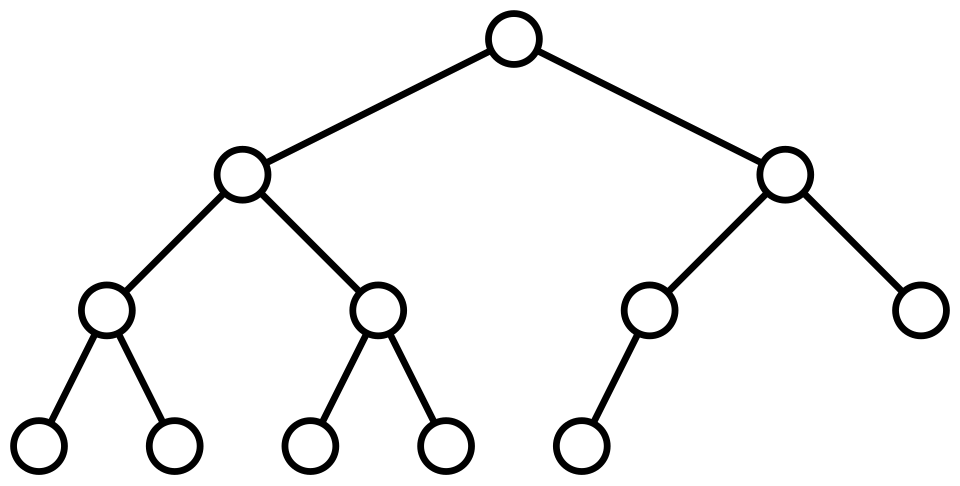

> 📷 二叉树：每个节点最多两个孩子（左子树/右子树）
> *图源：Wikimedia Commons（开放授权）*


## §1 心智模型与遍历分类

### 树的递归结构

二叉树本身是递归定义的：

$$\text{node} = \text{val} + \text{left} + \text{right}$$

所以**所有二叉树问题优先想递归**：把子树当成「已经解决的黑盒」。

### 三种深度遍历 + 层序

| 遍历 | 顺序 | 典型用途 |
|------|------|---------|
| 前序 | 根 → 左 → 右 | 序列化、构造树 |
| 中序 | 左 → 根 → 右 | **BST 有序输出** |
| 后序 | 左 → 右 → 根 | **自底向上计算**（深度、路径、直径） |
| 层序 | 逐层 | 最短路径、右视图、每层处理 |

### 递归复杂度主公式

遍历/递归处理整棵树（每个节点访问一次）：

$$T(n) = 2T\left(\frac{n}{2}\right) + O(1) \implies T(n) = O(n)$$

空间 = 递归栈深度 $O(h)$（$h$ 为树高，最坏 $O(n)$）。

## §2 递归遍历三件套（背熟）

三种递归遍历只有一行顺序不同：

```python
def order(root, res):
    if root is None:
        return
    # 前序：res.append(root.val)  放这里
    order(root.left, res)
    # 中序：res.append(root.val)  放这里
    order(root.right, res)
    # 后序：res.append(root.val)  放这里
```

**复杂度**：时间 $O(n)$（每节点一次），空间 $O(h)$（递归栈）。

> ⚠️ **中序的重要性质**：二叉搜索树（BST）的中序遍历结果**严格递增**——这是 98 题的核心。

In [ ]:
class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

def build_tree(arr):
    # 层序数组构造二叉树：None 表示空节点
    if not arr:
        return None
    from collections import deque
    root = TreeNode(arr[0])
    q = deque([root])
    i = 1
    while q and i < len(arr):
        node = q.popleft()
        if arr[i] is not None:
            node.left = TreeNode(arr[i])
            q.append(node.left)
        i += 1
        if i < len(arr) and arr[i] is not None:
            node.right = TreeNode(arr[i])
            q.append(node.right)
        i += 1
    return root

def preorder(root, res):
    if root is None:
        return
    res.append(root.val)
    preorder(root.left, res)
    preorder(root.right, res)

def inorder(root, res):
    if root is None:
        return
    inorder(root.left, res)
    res.append(root.val)
    inorder(root.right, res)

def postorder(root, res):
    if root is None:
        return
    postorder(root.left, res)
    postorder(root.right, res)
    res.append(root.val)

t = build_tree([1, 2, 3, 4, 5])
a, b, c = [], [], []
preorder(t, a); inorder(t, b); postorder(t, c)
print('前序:', a)    # 期望 [1, 2, 4, 5, 3]
print('中序:', b)    # 期望 [4, 2, 5, 1, 3]
print('后序:', c)    # 期望 [4, 5, 2, 3, 1]

## §3 迭代遍历 + 层序（BFS）

### 迭代前序（栈模拟，面试要求）

```python
stack = [root]
while stack:
    node = stack.pop()
    res.append(node.val)
    if node.right: stack.append(node.right)   # 右先入栈后出
    if node.left:  stack.append(node.left)
```

### 层序（队列 BFS，102 题）

```python
q = deque([root])
while q:
    level = []
    for _ in range(len(q)):      # 按层取出
        node = q.popleft()
        level.append(node.val)
        if node.left: q.append(node.left)
        if node.right: q.append(node.right)
    res.append(level)
```

**复杂度**：两者均为 $O(n)$ 时间、$O(n)$ 空间（最宽一层）。

In [ ]:
from collections import deque

def preorder_iter(root):
    res = []
    stack = [root]
    while stack:
        node = stack.pop()
        if node is None:
            continue
        res.append(node.val)
        stack.append(node.right)   # 右先入栈（后出）
        stack.append(node.left)    # 左后入栈（先出）
    return res

def level_order(root):
    if root is None:
        return []
    res = []
    q = deque([root])
    while q:
        level = []
        for _ in range(len(q)):
            node = q.popleft()
            level.append(node.val)
            if node.left:
                q.append(node.left)
            if node.right:
                q.append(node.right)
        res.append(level)
    return res

t = build_tree([3, 9, 20, None, None, 15, 7])
print('迭代前序:', preorder_iter(t))   # 期望 [3, 9, 20, 15, 7]
print('层序:', level_order(t))          # 期望 [[3], [9, 20], [15, 7]]
print('层序(空树):', level_order(None))  # 期望 []

In [ ]:
def inorder_iter(root):
    # 迭代中序：显式栈，左链入栈 -> 弹栈访问 -> 转向右子树
    res = []
    stack = []
    cur = root
    while cur or stack:
        while cur:                # 左链全部入栈
            stack.append(cur)
            cur = cur.left
        cur = stack.pop()         # 弹栈访问
        res.append(cur.val)
        cur = cur.right           # 转向右子树
    return res

def postorder_iter(root):
    # 迭代后序（前序反转变体）：先收集 根-右-左，最后整体反转得 左-右-根
    res = []
    stack = [root]
    while stack:
        node = stack.pop()
        if node is None:
            continue
        res.append(node.val)
        stack.append(node.left)   # 左先入栈 -> 右先出栈，得到 根-右-左
        stack.append(node.right)
    return res[::-1]

t3 = build_tree([1, 2, 3])        # 根 1，左 2，右 3
assert inorder_iter(t3) == [2, 1, 3], inorder_iter(t3)
assert postorder_iter(t3) == [2, 3, 1], postorder_iter(t3)

t5 = build_tree([1, 2, 3, 4, 5])
print('迭代中序:', inorder_iter(t5))     # 期望 [4, 2, 5, 1, 3]
print('迭代后序:', postorder_iter(t5))   # 期望 [4, 5, 2, 3, 1]
print('迭代中序(空树):', inorder_iter(None))   # 期望 []
print('迭代后序(空树):', postorder_iter(None)) # 期望 []


## §4 深度 / 直径 / 最大路径和（后序套路）

### 104 最大深度

$$\text{depth}(node) = 1 + \max(\text{depth}(left),\ \text{depth}(right))$$

### 543 二叉树的直径（最长路径长度 = 边数）

经过某节点的最长路径 = 左子树深度 + 右子树深度：

$$\text{diameter} = \max_{node}\, (h_{left} + h_{right})$$

**后序**：返回「子树高度」，过程中更新全局直径。

### 124 二叉树中的最大路径和

$$\text{gain}(node) = val + \max(0, gain_{left}) + \max(0, gain_{right})$$

$$\text{best} = \max_{node}\, (val + \max(0, gain_{left}) + \max(0, gain_{right}))$$

注意：返回给父节点的是**单侧**最大增益 $val + \max(gain_{left}, gain_{right})$（路径不能分叉两次）。

In [ ]:
def max_depth(root):
    if root is None:
        return 0
    return 1 + max(max_depth(root.left), max_depth(root.right))

def diameter_of_binary_tree(root):
    best = 0
    def dfs(node):
        nonlocal best
        if node is None:
            return 0
        l = dfs(node.left)
        r = dfs(node.right)
        best = max(best, l + r)      # 经过当前节点的路径
        return 1 + max(l, r)         # 返回子树高度
    dfs(root)
    return best

def max_path_sum(root):
    best = float('-inf')
    def dfs(node):
        nonlocal best
        if node is None:
            return 0
        l = max(dfs(node.left), 0)    # 负数分支不取
        r = max(dfs(node.right), 0)
        best = max(best, node.val + l + r)   # 经过当前节点
        return node.val + max(l, r)          # 单侧增益给父节点
    dfs(root)
    return best

t1 = build_tree([3, 9, 20, None, None, 15, 7])
print('max_depth:', max_depth(t1))                        # 期望 3
print('diameter:', diameter_of_binary_tree(t1))           # 期望 3（9-3-20-15 或 7-20-15）
t2 = build_tree([-10, 9, 20, None, None, 15, 7])
print('max_path_sum:', max_path_sum(t2))                  # 期望 42（15+20+7）
print('max_path_sum 单节点:', max_path_sum(TreeNode(-3)))  # 期望 -3（必须含一个节点）

### 110 平衡二叉树判断思路（后序 + 高度传递）

- 后序遍历：先算完左右子树高度，再比较当前节点——自底向上，天然契合「平衡」定义。
- 任一子树返回 `-1` 即已失衡；左右高度差 $> 1$ 时直接判定 `False`。
- 两侧都平衡则返回 `max(左高, 右高) + 1` 向上传递；空节点高度为 `0`。
- 递归同时返回「是否平衡 + 高度」两信息，一次后序 O(n) 完成判断。

## §5 二叉搜索树（BST）三题

**BST 性质**：左子树所有值 $<$ 根 $<$ 右子树所有值；中序遍历严格递增。

### 98 验证二叉搜索树（经典坑）

**错误做法**：只比较 `left.val < root.val < right.val`——会漏掉「左子树的右子树里有大于根的值」的情况（如 `[5,4,6,null,null,3,7]`）。

**正确做法**：递归携带**上下界区间** $(lo, hi)$：

$$\text{valid}(node, lo, hi) = lo < node.val < hi \land \text{valid}(left, lo, node.val) \land \text{valid}(right, node.val, hi)$$

### 230 二叉搜索树中第 K 小的元素

**思路**：中序遍历第 $k$ 个即答案——$O(h)$ 用 Morris/迭代中序，$O(n)$ 直接中序。

### 108 有序数组转换为高度平衡 BST

**思路**：每次取中点为根，递归左右——天然平衡：

$$\text{root} = arr[mid], \quad \text{left} = f(l, mid-1), \quad \text{right} = f(mid+1, r)$$

In [ ]:
def is_valid_bst(root):
    def dfs(node, lo, hi):
        if node is None:
            return True
        if not (lo < node.val < hi):
            return False
        return dfs(node.left, lo, node.val) and dfs(node.right, node.val, hi)
    return dfs(root, float('-inf'), float('inf'))

def kth_smallest(root, k):
    # 迭代中序，第 k 个弹出的就是答案
    stack = []
    cur = root
    while cur or stack:
        while cur:
            stack.append(cur)
            cur = cur.left
        cur = stack.pop()
        k -= 1
        if k == 0:
            return cur.val
        cur = cur.right

def sorted_array_to_bst(nums):
    if not nums:
        return None
    mid = len(nums) // 2
    root = TreeNode(nums[mid])
    root.left = sorted_array_to_bst(nums[:mid])
    root.right = sorted_array_to_bst(nums[mid + 1:])
    return root

print('valid BST:', is_valid_bst(build_tree([2, 1, 3])))                  # 期望 True
print('invalid(经典反例):', is_valid_bst(build_tree([5, 4, 6, None, None, 3, 7])))  # 期望 False
bst = build_tree([3, 1, 4, None, 2])
print('kth_smallest(1):', kth_smallest(bst, 1))    # 期望 1
print('kth_smallest(3):', kth_smallest(bst, 3))    # 期望 3
bal = sorted_array_to_bst([-10, -3, 0, 5, 9])
print('有序数组->BST 前序:', preorder_iter(bal))     # 期望 [0, -10, -3, 5, 9]

In [ ]:
def bst_insert(root, val):
    # 递归插入：小于走左、大于走右、空位新建节点，返回新根
    if root is None:
        return TreeNode(val)
    if val < root.val:
        root.left = bst_insert(root.left, val)
    elif val > root.val:
        root.right = bst_insert(root.right, val)
    return root

def bst_min(node):
    # 右子树最小节点：一路向左
    while node.left:
        node = node.left
    return node

def bst_delete(root, val):
    # 三种情形：无子（直接删）/ 单子（子节点顶替）/ 双子（右子树最小节点替换）
    if root is None:
        return None
    if val < root.val:
        root.left = bst_delete(root.left, val)
    elif val > root.val:
        root.right = bst_delete(root.right, val)
    else:
        if root.left is None:
            return root.right    # 无左子：右子顶替（含叶子情形）
        if root.right is None:
            return root.left     # 无右子：左子顶替
        # 双子：取右子树最小节点替换当前值，再删除该最小节点
        succ = bst_min(root.right)
        root.val = succ.val
        root.right = bst_delete(root.right, succ.val)
    return root

def inorder_vals(root):
    res = []
    inorder(root, res)   # 复用 §2 的递归中序
    return res

nums = [5, 3, 7, 2, 4, 6, 8]
bst = None
for v in nums:
    bst = bst_insert(bst, v)
assert inorder_vals(bst) == sorted(nums), inorder_vals(bst)   # 插入后中序严格有序

bst = bst_delete(bst, 2)   # 删叶子（无子）
assert inorder_vals(bst) == [3, 4, 5, 6, 7, 8], inorder_vals(bst)

bst = bst_delete(bst, 3)   # 删单子节点（3 仅剩右子 4）
assert inorder_vals(bst) == [4, 5, 6, 7, 8], inorder_vals(bst)

bst = bst_delete(bst, 5)   # 删双子根节点（右子树最小 6 替换）
assert inorder_vals(bst) == [4, 6, 7, 8], inorder_vals(bst)

print('BST 插入/删除后中序:', inorder_vals(bst))   # 期望 [4, 6, 7, 8]


## §6 最近公共祖先（LeetCode 236）

**题目**：二叉树中 $p$、$q$ 的最近公共祖先（LCA）。

**递归三分法**：对节点 $node$：

$$f(node) = \begin{cases} node & node = p \text{ 或 } q \\ \text{left 结果} & \text{left 非空且 right 为空} \\ \text{right 结果} & \text{right 非空且 left 为空} \\ node & \text{左右都非空（分属两侧，node 即 LCA）} \end{cases}$$

**三种情形**：

1. $p$、$q$ 都在左子树 → 返回左子树结果
2. 都在右子树 → 返回右子树结果
3. **分属两侧**（或之一是 root）→ 当前节点即 LCA

**复杂度**：时间 $O(n)$（每个节点访问一次），空间 $O(h)$。

In [ ]:
def lowest_common_ancestor(root, p, q):
    if root is None or root is p or root is q:
        return root
    left = lowest_common_ancestor(root.left, p, q)
    right = lowest_common_ancestor(root.right, p, q)
    if left and right:
        return root            # 分属两侧：root 是 LCA
    return left if left else right

# 构造：        3
#           /     \
#          5       1
#         / \     / \
#        6   2   0   8
#           / \
#          7   4
arr = [3, 5, 1, 6, 2, 0, 8, None, None, 7, 4]
t = build_tree(arr)
p5, q1 = t.left, t.right          # 5 和 1
print('LCA(5,1) =', lowest_common_ancestor(t, p5, q1).val)      # 期望 3
p4 = t.left.right.right           # 4
p5_ = t.left
print('LCA(4,5) =', lowest_common_ancestor(t, p4, p5_).val)     # 期望 5
p7 = t.left.right.left            # 7
print('LCA(7,4) =', lowest_common_ancestor(t, p7, p4).val)      # 期望 2

## §7 对称 / 右视图（层序变体）

### 101 对称二叉树

**递归镜像比较**：

$$\text{sym}(l, r) = l.val = r.val \land \text{sym}(l.left, r.right) \land \text{sym}(l.right, r.left)$$

### 199 二叉树的右视图

**思路**：层序遍历，**每层最后一个节点**即右视图所见。

**复杂度**：均为 $O(n)$ 时间、$O(w)$ 空间（w 为最大层宽）。

In [ ]:
def is_symmetric(root):
    def mirror(l, r):
        if l is None and r is None:
            return True
        if l is None or r is None:
            return False
        return (l.val == r.val
                and mirror(l.left, r.right)
                and mirror(l.right, r.left))
    return mirror(root.left, root.right) if root else True

def right_side_view(root):
    if root is None:
        return []
    res = []
    q = deque([root])
    while q:
        level = []
        for _ in range(len(q)):
            node = q.popleft()
            level.append(node.val)
            if node.left:
                q.append(node.left)
            if node.right:
                q.append(node.right)
        res.append(level[-1])    # 每层最后一个 = 右视图
    return res

print('对称:', is_symmetric(build_tree([1, 2, 2, 3, 4, 4, 3])))   # 期望 True
print('不对称:', is_symmetric(build_tree([1, 2, 2, None, 3, None, 3])))  # 期望 False
print('右视图:', right_side_view(build_tree([1, 2, 3, None, 5, None, 4])))  # 期望 [1,3,4]
print('右视图(空):', right_side_view(None))                        # 期望 []

## §8 序列化与构造（297 / 105）

### 297 二叉树的序列化与反序列化（前序 + None 标记）

**编码**：前序遍历，空节点记为 `None`：`1,2,None,None,3,4,None,None,5,None,None`。

**解码**：递归消费列表——读到 None 返回空，否则建节点并递归左右。

**为什么前序 + None 够用**：None 标记补全了树形信息，不需要中序辅助。

### 105 从前序与中序遍历构造二叉树

**核心公式**：前序第一个是根；根在中序中的位置 $i$ 把中序切成左右两段：

$$\text{left\_size} = i - \text{in\_start}, \quad \text{right\_size} = \text{in\_end} - i$$

左子树 = 前序 `[pre_start+1, pre_start+left_size]` × 中序 `[in_start, i-1]`，右子树同理。

**复杂度**：$O(n)$（用哈希表记录中序值 → 下标）。

In [ ]:
def serialize(root):
    res = []
    def dfs(node):
        if node is None:
            res.append('None')
            return
        res.append(str(node.val))
        dfs(node.left)
        dfs(node.right)
    dfs(root)
    return ','.join(res)

def deserialize(data):
    it = iter(data.split(','))
    def dfs():
        v = next(it)
        if v == 'None':
            return None
        node = TreeNode(int(v))
        node.left = dfs()
        node.right = dfs()
        return node
    return dfs()

t = build_tree([1, 2, 3, None, None, 4, 5])
s = serialize(t)
print('序列化:', s)
t2 = deserialize(s)
print('反序列化后前序一致:', preorder_iter(t2) == preorder_iter(t))

def build_from_pre_in(preorder, inorder):
    idx = {v: i for i, v in enumerate(inorder)}
    def dfs(ps, pe, is_, ie):
        if ps > pe:
            return None
        root = TreeNode(preorder[ps])
        i = idx[root.val]                 # 根在中序中的位置
        left_size = i - is_
        root.left = dfs(ps + 1, ps + left_size, is_, i - 1)
        root.right = dfs(ps + left_size + 1, pe, i + 1, ie)
        return root
    return dfs(0, len(preorder) - 1, 0, len(inorder) - 1)

rt = build_from_pre_in([3, 9, 20, 15, 7], [9, 3, 15, 20, 7])
print('105 构造结果前序:', preorder_iter(rt))   # 期望 [3, 9, 20, 15, 7]

## §9 复杂度总表（背熟）

| 题 | 时间 | 空间 | 核心技巧 |
|----|------|------|---------|
| 三种递归遍历 | $O(n)$ | $O(h)$ | 递归顺序 |
| 层序 102 | $O(n)$ | $O(w)$ | 队列按层 |
| 最大深度 104 | $O(n)$ | $O(h)$ | 后序 |
| 直径 543 | $O(n)$ | $O(h)$ | 后序 + 全局 |
| 最大路径和 124 | $O(n)$ | $O(h)$ | 后序 + 单侧增益 |
| 验证 BST 98 | $O(n)$ | $O(h)$ | 区间下传 |
| LCA 236 | $O(n)$ | $O(h)$ | 三分法 |
| 序列化 297 | $O(n)$ | $O(n)$ | 前序 + None |
| 构造 105 | $O(n)$ | $O(n)$ | 哈希 + 分治 |

**一句话记忆**：树题复杂度几乎都是「每个节点访问一次」→ $O(n)$；区别只在返回什么、全局更新什么。

## §10 常见 bug 与边界（面试踩坑区）

- **空树**：`root is None` 必须在函数开头处理（遍历/深度/对称都问）
- **单节点**：路径和类题必须「至少取一个节点」，不能返回 0
- **BST 验证只比较相邻**：经典反例 `[5,4,6,null,null,3,7]`——必须传上下界区间
- **递归忘记返回**：后序返回高度/增益的函数，base case 返回 0 而非 None
- **层序按层取**：`for _ in range(len(q))` 时 len(q) 会随循环变化——先存长度或用快照
- **`nonlocal`**：在嵌套函数里更新全局 best，必须声明 `nonlocal best`（Python 3）
- **构建树的 None 处理**：层序构建数组里 None 占位，索引推进别漏
- **序列化类型**：把 int 转 str，反序列化再转回；None 用字符串标记不混淆

## §11 面试追问与扩展（加分项）

### 11.1 为什么后序适合自底向上

后序保证**先算完子树再算父节点**——深度、直径、路径和、树形 DP 全是后序；面试官问「为什么」时答「后序 = 子问题先求解」。

### 11.2 Morris 遍历（O(1) 空间）

利用线索：把左子树最右节点的 right 指向当前节点，遍历完再恢复。面试中提出能加分（中序 O(1) 空间）。

### 11.3 树形 DP 与后续专题

打家劫舍 III（337）、二叉树最大宽度（662）、路径总和 III（437）都是「树 + DP / 前缀和」组合，主题 8（DP）会回来。

### 11.4 满/完全/平衡树的区分

- 满二叉树：每层都满（节点数 $2^h - 1$）
- 完全二叉树：除最后一层外满，最后一层靠左
- 平衡二叉树：任意节点左右子树高度差 $\le 1$（110 题）

## §12 自测清单（L1 必会 / L2 进阶 / L3 挑战）

### L1 必会（10 题）

- [ ] 1. 二叉树的前序遍历（144）
- [ ] 2. 二叉树的中序遍历（94）
- [ ] 3. 二叉树的后序遍历（145）
- [ ] 4. 二叉树的层序遍历（102）
- [ ] 5. 二叉树的最大深度（104）
- [ ] 6. 对称二叉树（101）
- [ ] 7. 翻转二叉树（226）
- [ ] 8. 路径总和（112）
- [ ] 9. 二叉树的所有路径（257）
- [ ] 10. 相同的树（100）

### L2 进阶（10 题）

- [ ] 11. 验证二叉搜索树（98）
- [ ] 12. 二叉树的直径（543）
- [ ] 13. 二叉树的最近公共祖先（236）
- [ ] 14. 二叉树的右视图（199）
- [ ] 15. 二叉树的最大路径和（124）
- [ ] 16. 从前序与中序遍历序列构造二叉树（105）
- [ ] 17. 二叉树的序列化与反序列化（297）
- [ ] 18. 二叉搜索树中第 K 小的元素（230）
- [ ] 19. 平衡二叉树（110）
- [ ] 20. 把二叉搜索树转换为累加树（538）

### L3 挑战（5 题）

- [ ] 21. 二叉树的锯齿形层序遍历（103）
- [ ] 22. 打家劫舍 III（337，树形 DP）
- [ ] 23. 二叉树最大宽度（662）
- [ ] 24. 路径总和 III（437，前缀和）
- [ ] 25. 二叉树中的最长交错路径（1372）

### 自测要点

- 5 分钟内盲写：递归三序遍历 + 层序
- 讲清「BST 验证为什么必须传上下界」「LCA 三分法的三种情形」
- 能手推 124 的「返回单侧增益」与 543 的「返回高度」差异

## 附录：参考与下节预告

- 《算法导论》第 12 章：二叉搜索树；第 13 章：红黑树（了解）
- LeetCode 分类题单：二叉树 / BST

### 下节预告：主题 7 — 回溯（DFS + 撤销）

- 模板（选择-递归-撤销）、子集/组合/排列、剪枝、N 皇后、单词搜索

> 💡 本主题验收：`高频题单.md`「二叉树」一节全部打勾，能徒手画出 236 的三种递归返回情形。